### MAPAS DE RIESGO

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install janitor

In [3]:
!pip install descartes

In [4]:
import pandas as pd
import descartes  
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import datetime as dt
import random

In [6]:
!pip install geopandas

In [7]:
import geopandas as gpd

In [8]:
import json

In [9]:
import fiona; help(fiona.open)
import fiona; fiona.supported_drivers

Help on function open in module fiona:

open(fp, mode='r', driver=None, schema=None, crs=None, encoding=None, layer=None, vfs=None, enabled_drivers=None, crs_wkt=None, **kwargs)
    Open a collection for read, append, or write
    
    In write mode, a driver name such as "ESRI Shapefile" or "GPX" (see
    OGR docs or ``ogr2ogr --help`` on the command line) and a schema
    mapping such as:
    
      {'geometry': 'Point',
       'properties': [('class', 'int'), ('label', 'str'),
                      ('value', 'float')]}
    
    must be provided. If a particular ordering of properties ("fields"
    in GIS parlance) in the written file is desired, a list of (key,
    value) pairs as above or an ordered dict is required. If no ordering
    is needed, a standard dict will suffice.
    
    A coordinate reference system for collections in write mode can be
    defined by the ``crs`` parameter. It takes Proj4 style mappings like
    
      {'proj': 'longlat', 'ellps': 'WGS84', 'datum': 'W

{'DXF': 'rw',
 'CSV': 'raw',
 'OpenFileGDB': 'r',
 'ESRIJSON': 'r',
 'ESRI Shapefile': 'raw',
 'FlatGeobuf': 'rw',
 'GeoJSON': 'raw',
 'GeoJSONSeq': 'rw',
 'GPKG': 'raw',
 'GML': 'rw',
 'OGR_GMT': 'rw',
 'GPX': 'rw',
 'Idrisi': 'r',
 'MapInfo File': 'raw',
 'DGN': 'raw',
 'PCIDSK': 'raw',
 'OGR_PDS': 'r',
 'S57': 'r',
 'SQLite': 'raw',
 'TopoJSON': 'r'}

In [12]:
######################################################Para colab ###################################

# filename="/content/drive/MyDrive/bases/barrios.geojson"
# file = open(filename)
#df = gpd.read_file(file)

#df["geometry"] = df["geometry"].to_crs("EPSG:4326") OJO Mejor se deja asi tanto para colab como para el escritorio

In [55]:
filename="C:/Users/Keyla Alba/OneDrive - Universidad del Norte/Doctorado (Ciencias)/Mapas de Riesgo/bases/barrios.geojson"
file = open(filename)
df = gpd.read_file(file)

In [59]:
df.head(n=50)
df.shape
df.dtypes

Barrio         object
DANE           object
Localidad      object
ID             object
Area            int64
GEOID           int64
geometry     geometry
dtype: object

In [15]:
df["Barrio"].unique() 

array(['LA FLORIDA', 'SOLAIRE NORTE', 'BELLA ARENA', 'VILLA DEL ESTE',
       'AMERICA', 'SANTA MONICA', 'LOMA FRESCA', 'BARLOVENTO',
       'LOS PINOS', 'LAS MERCEDES', 'LA LIBERTAD', 'LOS JOBOS',
       'LAS COLINAS', 'LOS GIRASOLES', 'SANTO DOMINGO', 'TAYRONA',
       'ATLANTICO', 'ALTAMIRA', 'VILLA DEL CARMEN', 'PUMAREJO',
       'LAS TRES AVE MARIAS', 'LAS TERRAZAS', 'CONTINENTES', 'GRANADILLO',
       'ALFONSO LOPEZ', 'VILLA COUNTRY', 'SAN NICOLAS', 'BOYACA',
       'NUEVA GRANADA', 'MERCEDES SUR', 'LA CAMPIÃ‘A', 'ANDALUCIA',
       'VILLATE', 'BETANIA', 'CARLOS MEISEL', 'VILLA BLANCA',
       'CUCHILLA DE VILLATE', 'KENNEDY', 'LAS PALMERAS', 'MODELO',
       'LOS ANGELES II', 'LA CUMBRE', 'SANTA ANA', 'SANTA HELENA',
       'BUENA ESPERANZA', 'LA CEIBA', 'SAN FRANCISCO', 'LOS ALPES',
       'EL VALLE', 'SAN LUIS', 'LA ALBORAYA', 'EL POBLADO', 'CEVILLAR',
       '20 DE JULIO', 'BUENOS AIRES', 'LIPAYA', 'LOS ANDES', 'EL CAMPITO',
       'LOS OLIVOS I', 'LAS GRANJAS', 'LAS AMERICAS

<AxesSubplot:>

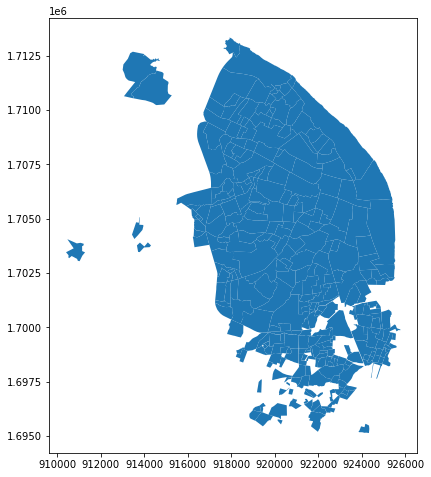

In [16]:
# graficando el mapa general
df.plot(figsize=(30,8))

In [17]:
from matplotlib import pyplot as plt 

([], [])

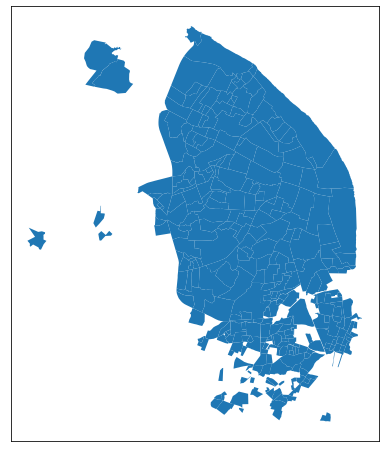

In [18]:
# graficando el mapa general sin valores en los ejes
df.plot(figsize=(30,8))
plt.xticks([])
plt.yticks([])

In [ ]:
#######################  PARA COLAB   ###############################

# DATOS_mcol = gpd.read_file("/content/drive/MyDrive/bases/DELITOS POR MOTO.shp",encoding="latin1")# leyendo la matriz de datos (.shp) con las georeferencias 
# DATOS_mcol.head(n=33)
#DATOS_mcol["geometry"] = DATOS_mcol["geometry"].to_crs("EPSG:4326") #OJO MEJOR DEJARLO ASI TANTO PARA COLAB COMO PARA ESCRITORIO

In [60]:
DATOS_mcol = gpd.read_file("C:/Users/Keyla Alba/OneDrive - Universidad del Norte/Doctorado (Ciencias)/Mapas de Riesgo/bases/DELITOS POR MOTO.shp",encoding="latin1")
DATOS_mcol.head(n=33)
print (DATOS_mcol.shape)

(161, 13)


In [20]:
DATOS_mcol.tail(n=5)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry
156,VILLA CAMPESTRE,914574.134,1710965.181,157,0.0,51.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((914032.844 1710447.745, 913553.754 1..."
157,LA PLAYA,913738.649,1711814.409,158,3.0,158.0,0.0,0.0,0.0,5.0,0.0,5.0,"POLYGON ((913039.255 1710618.184, 913209.709 1..."
158,MIRAMAR,917078.327,1708514.361,159,0.0,90.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((916895.464 1707485.063, 916888.631 1..."
159,BUENAVISTA,NaN,NaN,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((918844.092 1710531.083, 918775.456 1..."
160,VILLA CAROLINA,NaN,NaN,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((919471.978 1710989.118, 919602.222 1..."


In [21]:
DATOS_mcol.at[19,'NOMBRE_DE_']="LA CAMPIÑA"
DATOS_mcol.head(n=50)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1..."
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1..."
2,ANDALUCIA,919482.977,1710057.209,3,0.0,29.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((919853.983 1710203.244, 919854.757 1..."
3,SIAPE,920835.114,1711261.932,4,1.0,50.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920629.577 1711241.764, 920625.719 1..."
4,SAN SALVADOR,920525.957,1710954.168,5,2.0,65.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920250.386 1710910.518, 920229.796 1..."
5,SOLAIRE,919936.438,1709987.659,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((919945.891 1709781.171, 919937.716 1..."
6,VILLA DEL ESTE,919793.447,1709812.330,7,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((919862.440 1709648.960, 919855.373 1..."
7,RIOMAR,919375.497,1709557.024,8,0.0,149.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((919846.437 1709546.638, 919840.574 1..."
8,EL GOLF,920069.614,1709342.943,9,0.0,65.0,0.0,3.0,0.0,0.0,0.0,3.0,"POLYGON ((920497.411 1709313.837, 920494.243 1..."
9,VILLA COUNTRY,920498.988,1708996.498,10,0.0,83.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((920633.291 1709295.355, 920636.886 1..."


In [22]:
DATOS_mcol["NOMBRE_DE_"].unique() 

array(['LAS FLORES', 'EL LIMONCITO', 'ANDALUCIA', 'SIAPE', 'SAN SALVADOR',
       'SOLAIRE', 'VILLA DEL ESTE', 'RIOMAR', 'EL GOLF', 'VILLA COUNTRY',
       'LA CONCEPCION', 'ALTOS DEL LIMON', 'SANTA MONICA', 'ALTAMIRA',
       'SAN VICENTE', 'ALTOS DEL PRADO', 'VILLA SANTOS', 'EL POBLADO',
       'EL TABOR', 'LA CAMPIÑA', 'LA CUMBRE', 'LOS ALPES',
       'NUEVO HORIZONTE', 'GRANADILLO', 'LOS NOGALES', 'EL PORVENIR',
       'LA FLORIDA', 'LAS TERRAZAS', 'LOS JOBOS', 'LAS MERCEDES',
       'BETANIA', 'LAS DELICIAS', 'EL PRADO', 'BELLAVISTA',
       'SAN FRANCISCO', 'SANTA ANA', 'MODELO', 'MONTECRISTO', 'BOSTON',
       'ABAJO', 'BARLOVENTO', 'EL ROSARIO', 'CENTRO', 'VILLANUEVA',
       'LA LIBERTAD', 'CARLOS MEISEL', 'NUEVA COLOMBIA', 'NUEVA GRANADA',
       'SANTO DOMINGO', 'EL RECREO', 'SAN FELIPE', 'LOS ANDES',
       'LOS PINOS', 'CIUDADELA  DE LA SALUD', 'LOMA FRESCA', 'SAN ISIDRO',
       'CHIQUINQUIRA', 'ATLANTICO', 'ALFONSO LOPEZ', 'SAN ROQUE',
       'REBOLO', 'LA LUZ', 'LA CHIN

In [23]:
DATOS_mcol["ID"].unique() 

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161], dtype=int64)

<AxesSubplot:>

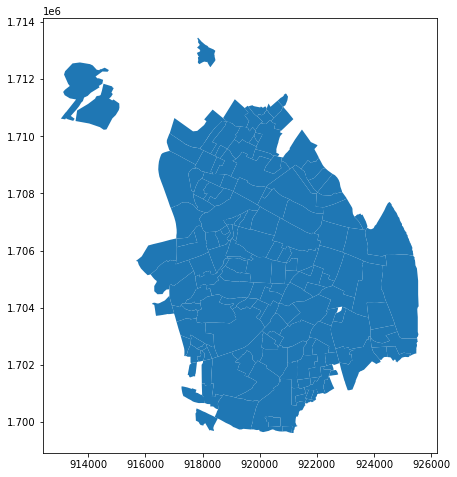

In [24]:
# graficando el mapa general
DATOS_mcol.plot(figsize=(30,8))

([], [])

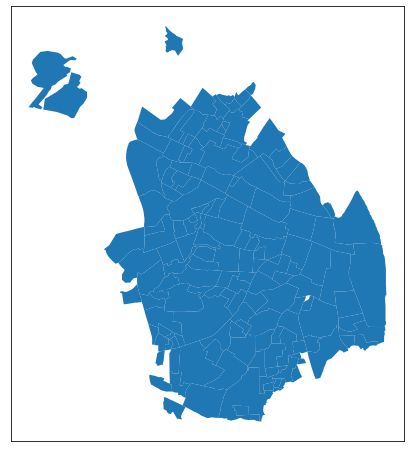

In [25]:
DATOS_mcol.plot(figsize=(30,8))
plt.xticks([])
plt.yticks([])

In [ ]:
#########################  PARA COLAB   ##########################################

# direccion="/content/drive/MyDrive/bases/baseactualizada.xlsx" # cargando matriz de datos 
# BAQ=pd.read_excel(direccion,header=0) # leyendo matriz de datos, header= 0 es para leerprimera fila como los nombres
# BAQ.head(n=2)

In [38]:
direccion="C:/Users/Keyla Alba/OneDrive - Universidad del Norte/Doctorado (Ciencias)/Mapas de Riesgo/bases/baseactualizada.xlsx" # cargando matriz de datos 
BAQ=pd.read_excel(direccion,header=0) # leyendo matriz de datos, header= 0 es para leerprimera fila como los nombres
BAQ.head(n=2)

,Fecha,Año,Delito,DELITO_COD,Mes,Departamento,Municipio,Día,g,Hora_D,BARRIO_COD,SITIO_COD,ARMA_COD,Edad,SEXO_COD,Nacionalidad,Cantidad
0,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,20:45:00,20,100,1,2,19,1,1,1
1,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,21:45:00,21,61,1,3,58,2,4,1


In [27]:
BAQ.columns

Index(['Fecha', 'Año', 'Delito', 'DELITO_COD', 'Mes', 'Departamento',
       'Municipio', 'Día', 'g', 'Hora_D', 'BARRIO_COD', 'SITIO_COD',
       'ARMA_COD', 'Edad', 'SEXO_COD', 'Nacionalidad', 'Cantidad'],
      dtype='object')

In [28]:
BAQ.dtypes # tipo de variables en la matriz

Fecha           datetime64[ns]
Año                      int64
Delito                  object
DELITO_COD               int64
Mes                      int64
Departamento            object
Municipio               object
Día                     object
g                       object
Hora_D                   int64
BARRIO_COD               int64
SITIO_COD                int64
ARMA_COD                 int64
Edad                     int64
SEXO_COD                 int64
Nacionalidad             int64
Cantidad                 int64
dtype: object

In [32]:
#BAQ["BARRIO_COD"] = BAQ["BARRIO_COD"].astype("category")

In [46]:
#Para crear un resumen agrupando por las variables BARRIO_COD y CANTIDAD, las tres variabbles numericas de los datos
resum_3 = BAQ.groupby(["BARRIO_COD"]).sum()[["Cantidad"]]
 
resum_3

,Cantidad
BARRIO_COD,
1,44
2,2
4,10
5,5
8,3
...,...
155,5
158,37
159,2


In [47]:
resum_3.reset_index(inplace=True) # para evitar que la variable sea leida como indice

resum_3

,BARRIO_COD,Cantidad
0,1,44
1,2,2
2,4,10
3,5,5
4,8,3
...,...,...
132,155,5
133,158,37
134,159,2
135,161,2


In [48]:
resum_3['Cantidad'] = resum_3['Cantidad'].fillna(0)

In [49]:
resum_3.tail(n=5) 

,BARRIO_COD,Cantidad
132,155,5
133,158,37
134,159,2
135,161,2
136,163,2


In [50]:
resum_3=resum_3[resum_3["BARRIO_COD"]<162]#Se excluye juan mina y otros barrios fuera de barranquilla
resum_3.tail(n=5)

,BARRIO_COD,Cantidad
131,154,7
132,155,5
133,158,37
134,159,2
135,161,2


In [51]:
# para cambiar el nombre BARRIO_COD por departamento ID y coincida con la anterior matriz de datos 
resum_3.rename(columns={"BARRIO_COD": "ID"},inplace=True)
resum_3.head()

C:\Users\Keyla Alba\AppData\Local\Temp\ipykernel_9336\903726686.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resum_3.rename(columns={"BARRIO_COD": "ID"},inplace=True)


,ID,Cantidad
0,1,44
1,2,2
2,4,10
3,5,5
4,8,3


In [52]:
resum_3.tail()

,ID,Cantidad
131,154,7
132,155,5
133,158,37
134,159,2
135,161,2


In [53]:
MAP=pd.merge(DATOS_mcol,resum_3, on = 'ID',how = 'outer')# para unir las dos matrices por departamento y quede en la matriz
#con georeferenias y la cantidad de delitos
MAP.head(n=2)


,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry,Cantidad
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1...",44.0
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1...",2.0


In [61]:
DATOS_mcol.head(n=50)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1..."
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1..."
2,ANDALUCIA,919482.977,1710057.209,3,0.0,29.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((919853.983 1710203.244, 919854.757 1..."
3,SIAPE,920835.114,1711261.932,4,1.0,50.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920629.577 1711241.764, 920625.719 1..."
4,SAN SALVADOR,920525.957,1710954.168,5,2.0,65.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920250.386 1710910.518, 920229.796 1..."
5,SOLAIRE,919936.438,1709987.659,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((919945.891 1709781.171, 919937.716 1..."
6,VILLA DEL ESTE,919793.447,1709812.330,7,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((919862.440 1709648.960, 919855.373 1..."
7,RIOMAR,919375.497,1709557.024,8,0.0,149.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((919846.437 1709546.638, 919840.574 1..."
8,EL GOLF,920069.614,1709342.943,9,0.0,65.0,0.0,3.0,0.0,0.0,0.0,3.0,"POLYGON ((920497.411 1709313.837, 920494.243 1..."
9,VILLA COUNTRY,920498.988,1708996.498,10,0.0,83.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((920633.291 1709295.355, 920636.886 1..."


In [62]:
DATOS_mcol.tail(n=50)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry
111,EL LIMON,922427.603,1701909.516,112,1.0,70.0,0.0,0.0,0.0,3.0,0.0,3.0,"POLYGON ((922527.726 1702031.183, 922540.890 1..."
112,EL MILAGRO,921749.805,1700961.857,113,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((921708.442 1701124.172, 921753.109 1..."
113,LUCERO,921539.252,1705733.950,114,1.0,127.0,0.0,7.0,0.0,12.0,0.0,19.0,"POLYGON ((921017.920 1706067.938, 921047.162 1..."
114,EL ROMANCE,918339.604,1702464.348,115,0.0,18.0,0.0,0.0,0.0,1.0,0.0,1.0,"POLYGON ((918163.543 1702614.863, 918158.867 1..."
115,KENNEDY,920310.430,1702778.941,116,1.0,41.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920637.922 1702551.871, 920624.669 1..."
116,EL SILENCIO,919239.757,1705983.141,117,1.0,157.0,0.0,9.0,0.0,4.0,0.0,13.0,"POLYGON ((919108.280 1706370.894, 919111.560 1..."
117,JOSE ANTONIO GALAN,922100.228,1701456.128,118,7.0,97.0,0.0,1.0,5.0,6.0,5.0,7.0,"POLYGON ((921785.735 1701328.682, 921788.394 1..."
118,LA DUNAS,921898.169,1701471.224,119,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((921764.162 1701537.604, 921945.415 1..."
119,LA VICTORIA,921268.823,1703090.335,120,1.0,198.0,0.0,7.0,0.0,11.0,0.0,18.0,"POLYGON ((921646.207 1702826.401, 921633.577 1..."
120,LAS MALVINAS,917745.518,1703185.346,121,20.0,101.0,0.0,0.0,2.0,3.0,2.0,3.0,"POLYGON ((917087.056 1703507.681, 917119.600 1..."


In [63]:
DATOS_mcol["NOMBRE_DE_"].unique() 

array(['LAS FLORES', 'EL LIMONCITO', 'ANDALUCIA', 'SIAPE', 'SAN SALVADOR',
       'SOLAIRE', 'VILLA DEL ESTE', 'RIOMAR', 'EL GOLF', 'VILLA COUNTRY',
       'LA CONCEPCION', 'ALTOS DEL LIMON', 'SANTA MONICA', 'ALTAMIRA',
       'SAN VICENTE', 'ALTOS DEL PRADO', 'VILLA SANTOS', 'EL POBLADO',
       'EL TABOR', 'LA CAMPIÃ\x91A', 'LA CUMBRE', 'LOS ALPES',
       'NUEVO HORIZONTE', 'GRANADILLO', 'LOS NOGALES', 'EL PORVENIR',
       'LA FLORIDA', 'LAS TERRAZAS', 'LOS JOBOS', 'LAS MERCEDES',
       'BETANIA', 'LAS DELICIAS', 'EL PRADO', 'BELLAVISTA',
       'SAN FRANCISCO', 'SANTA ANA', 'MODELO', 'MONTECRISTO', 'BOSTON',
       'ABAJO', 'BARLOVENTO', 'EL ROSARIO', 'CENTRO', 'VILLANUEVA',
       'LA LIBERTAD', 'CARLOS MEISEL', 'NUEVA COLOMBIA', 'NUEVA GRANADA',
       'SANTO DOMINGO', 'EL RECREO', 'SAN FELIPE', 'LOS ANDES',
       'LOS PINOS', 'CIUDADELA  DE LA SALUD', 'LOMA FRESCA', 'SAN ISIDRO',
       'CHIQUINQUIRA', 'ATLANTICO', 'ALFONSO LOPEZ', 'SAN ROQUE',
       'REBOLO', 'LA LUZ', 'LA 

In [64]:
MAP['Cantidad'] = MAP['Cantidad'].fillna(0)

In [65]:
DATOS_mcol

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1..."
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1..."
2,ANDALUCIA,919482.977,1710057.209,3,0.0,29.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((919853.983 1710203.244, 919854.757 1..."
3,SIAPE,920835.114,1711261.932,4,1.0,50.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920629.577 1711241.764, 920625.719 1..."
4,SAN SALVADOR,920525.957,1710954.168,5,2.0,65.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920250.386 1710910.518, 920229.796 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,VILLA CAMPESTRE,914574.134,1710965.181,157,0.0,51.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((914032.844 1710447.745, 913553.754 1..."
157,LA PLAYA,913738.649,1711814.409,158,3.0,158.0,0.0,0.0,0.0,5.0,0.0,5.0,"POLYGON ((913039.255 1710618.184, 913209.709 1..."
158,MIRAMAR,917078.327,1708514.361,159,0.0,90.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((916895.464 1707485.063, 916888.631 1..."
159,BUENAVISTA,NaN,NaN,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((918844.092 1710531.083, 918775.456 1..."


In [66]:
DATOS_mcol.to_excel('DATOS_mcol.xlsx')

In [67]:
DATOS_mcol.head(n=50)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1..."
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1..."
2,ANDALUCIA,919482.977,1710057.209,3,0.0,29.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((919853.983 1710203.244, 919854.757 1..."
3,SIAPE,920835.114,1711261.932,4,1.0,50.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920629.577 1711241.764, 920625.719 1..."
4,SAN SALVADOR,920525.957,1710954.168,5,2.0,65.0,0.0,1.0,0.0,1.0,0.0,2.0,"POLYGON ((920250.386 1710910.518, 920229.796 1..."
5,SOLAIRE,919936.438,1709987.659,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((919945.891 1709781.171, 919937.716 1..."
6,VILLA DEL ESTE,919793.447,1709812.330,7,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((919862.440 1709648.960, 919855.373 1..."
7,RIOMAR,919375.497,1709557.024,8,0.0,149.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((919846.437 1709546.638, 919840.574 1..."
8,EL GOLF,920069.614,1709342.943,9,0.0,65.0,0.0,3.0,0.0,0.0,0.0,3.0,"POLYGON ((920497.411 1709313.837, 920494.243 1..."
9,VILLA COUNTRY,920498.988,1708996.498,10,0.0,83.0,0.0,1.0,0.0,0.0,0.0,1.0,"POLYGON ((920633.291 1709295.355, 920636.886 1..."


In [68]:
resum_3.describe()

,ID,Cantidad
count,136.000000,136.000000
mean,82.397059,19.426471
std,44.565604,32.281776
min,1.000000,1.000000
25%,45.750000,3.000000
50%,81.500000,6.000000
75%,120.250000,20.500000
max,161.000000,210.000000


In [69]:
MAP.describe(include="all")

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry,Cantidad
count,161,159.000000,1.590000e+02,161.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,161,161.000000
unique,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161,NaN
top,LAS FLORES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POLYGON ((917842.5846864765 1713450.9322272616...,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
mean,NaN,920156.914239,1.705328e+06,81.000000,3.452830,110.742138,0.006289,1.899371,0.295597,2.635220,0.301887,4.534591,NaN,16.409938
std,NaN,2064.651863,3.023591e+03,46.620811,6.525217,130.520100,0.079305,2.250724,0.868240,3.294455,0.898344,5.076354,NaN,30.481033
min,NaN,913738.649000,1.699757e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,918543.105500,1.702729e+06,41.000000,0.000000,30.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,1.000000
50%,NaN,920069.614000,1.705122e+06,81.000000,1.000000,71.000000,0.000000,1.000000,0.000000,2.000000,0.000000,3.000000,NaN,5.000000
75%,NaN,921645.691000,1.707714e+06,121.000000,3.000000,152.000000,0.000000,3.000000,0.000000,4.000000,0.000000,6.500000,NaN,15.000000


In [70]:
MAP["rang_cant"] = pd.cut(MAP["Cantidad"],bins=[-1,5,15,25,50,150,250])#creando los rangos

C:\Users\Keyla Alba\anaconda3\lib\site-packages\geopandas\plotting.py:642: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(


(912413.21289359, 926186.128692231, 1698924.210277731, 1714142.680891525)

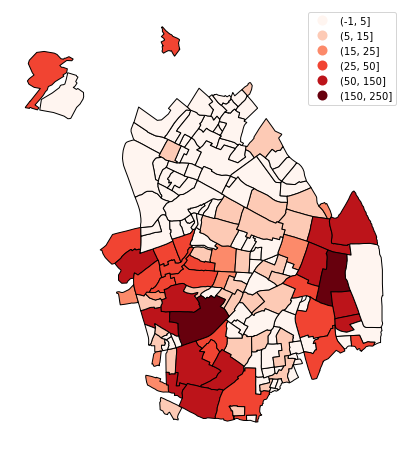

In [71]:
MAP.plot(column="rang_cant",figsize=(30,8), edgecolor="black", legend=True,colormap="Reds")
plt.axis('off')

In [72]:
MAP.loc[:, 'NOMBRE_DE_'] == 'SANTO DOMINGO'

0      False
1      False
2      False
3      False
4      False
       ...  
156    False
157    False
158    False
159    False
160    False
Name: NOMBRE_DE_, Length: 161, dtype: bool

In [73]:
MAP.loc[48]

NOMBRE_DE_                                        SANTO DOMINGO
X_Coord                                              920881.796
Y_Coord                                             1705838.305
ID                                                           49
HOM TOT                                                     0.0
HP TOT                                                      0.0
HOM CM                                                      0.0
HP CM                                                       0.0
HOM PM                                                      0.0
HP PM                                                       0.0
HOMICIDIOS                                                  0.0
HURTOS MOT                                                  0.0
geometry      POLYGON ((920829.6753709149 1706073.8226643119...
Cantidad                                                    1.0
rang_cant                                               (-1, 5]
Name: 48, dtype: object

In [74]:
MAP.loc[100]

NOMBRE_DE_                              SANTO DOMINGO DE GUZMAN
X_Coord                                               918933.76
Y_Coord                                             1701569.653
ID                                                          101
HOM TOT                                                    13.0
HP TOT                                                    153.0
HOM CM                                                      0.0
HP CM                                                       2.0
HOM PM                                                      0.0
HP PM                                                       6.0
HOMICIDIOS                                                  0.0
HURTOS MOT                                                  8.0
geometry      POLYGON ((919205.6184129626 1700899.6187808556...
Cantidad                                                   75.0
rang_cant                                             (50, 150]
Name: 100, dtype: object

C:\Users\Keyla Alba\anaconda3\lib\site-packages\geopandas\plotting.py:642: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(


([], [])

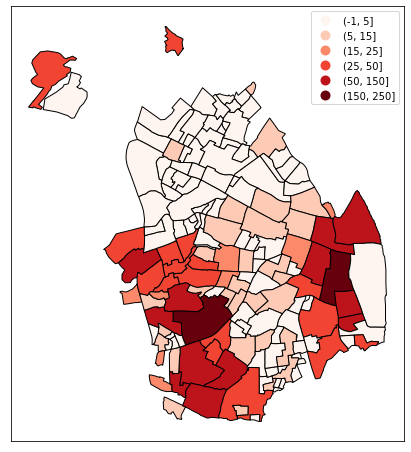

In [75]:
MAP.plot(column="rang_cant",figsize=(30,8) , legend=True, edgecolor='black',colormap="Reds")
plt.xticks([])
plt.yticks([])


([], [])

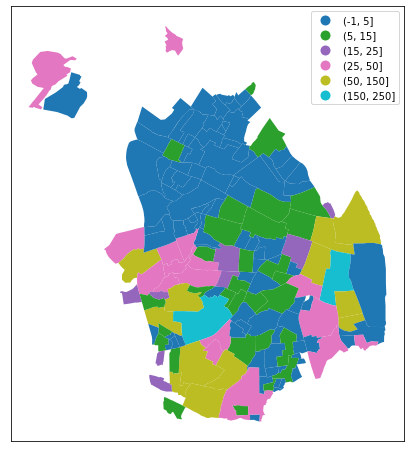

In [76]:
MAP.plot(column="rang_cant",figsize=(30,8), legend=True)
plt.xticks([])
plt.yticks([])

C:\Users\Keyla Alba\anaconda3\lib\site-packages\geopandas\plotting.py:642: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(


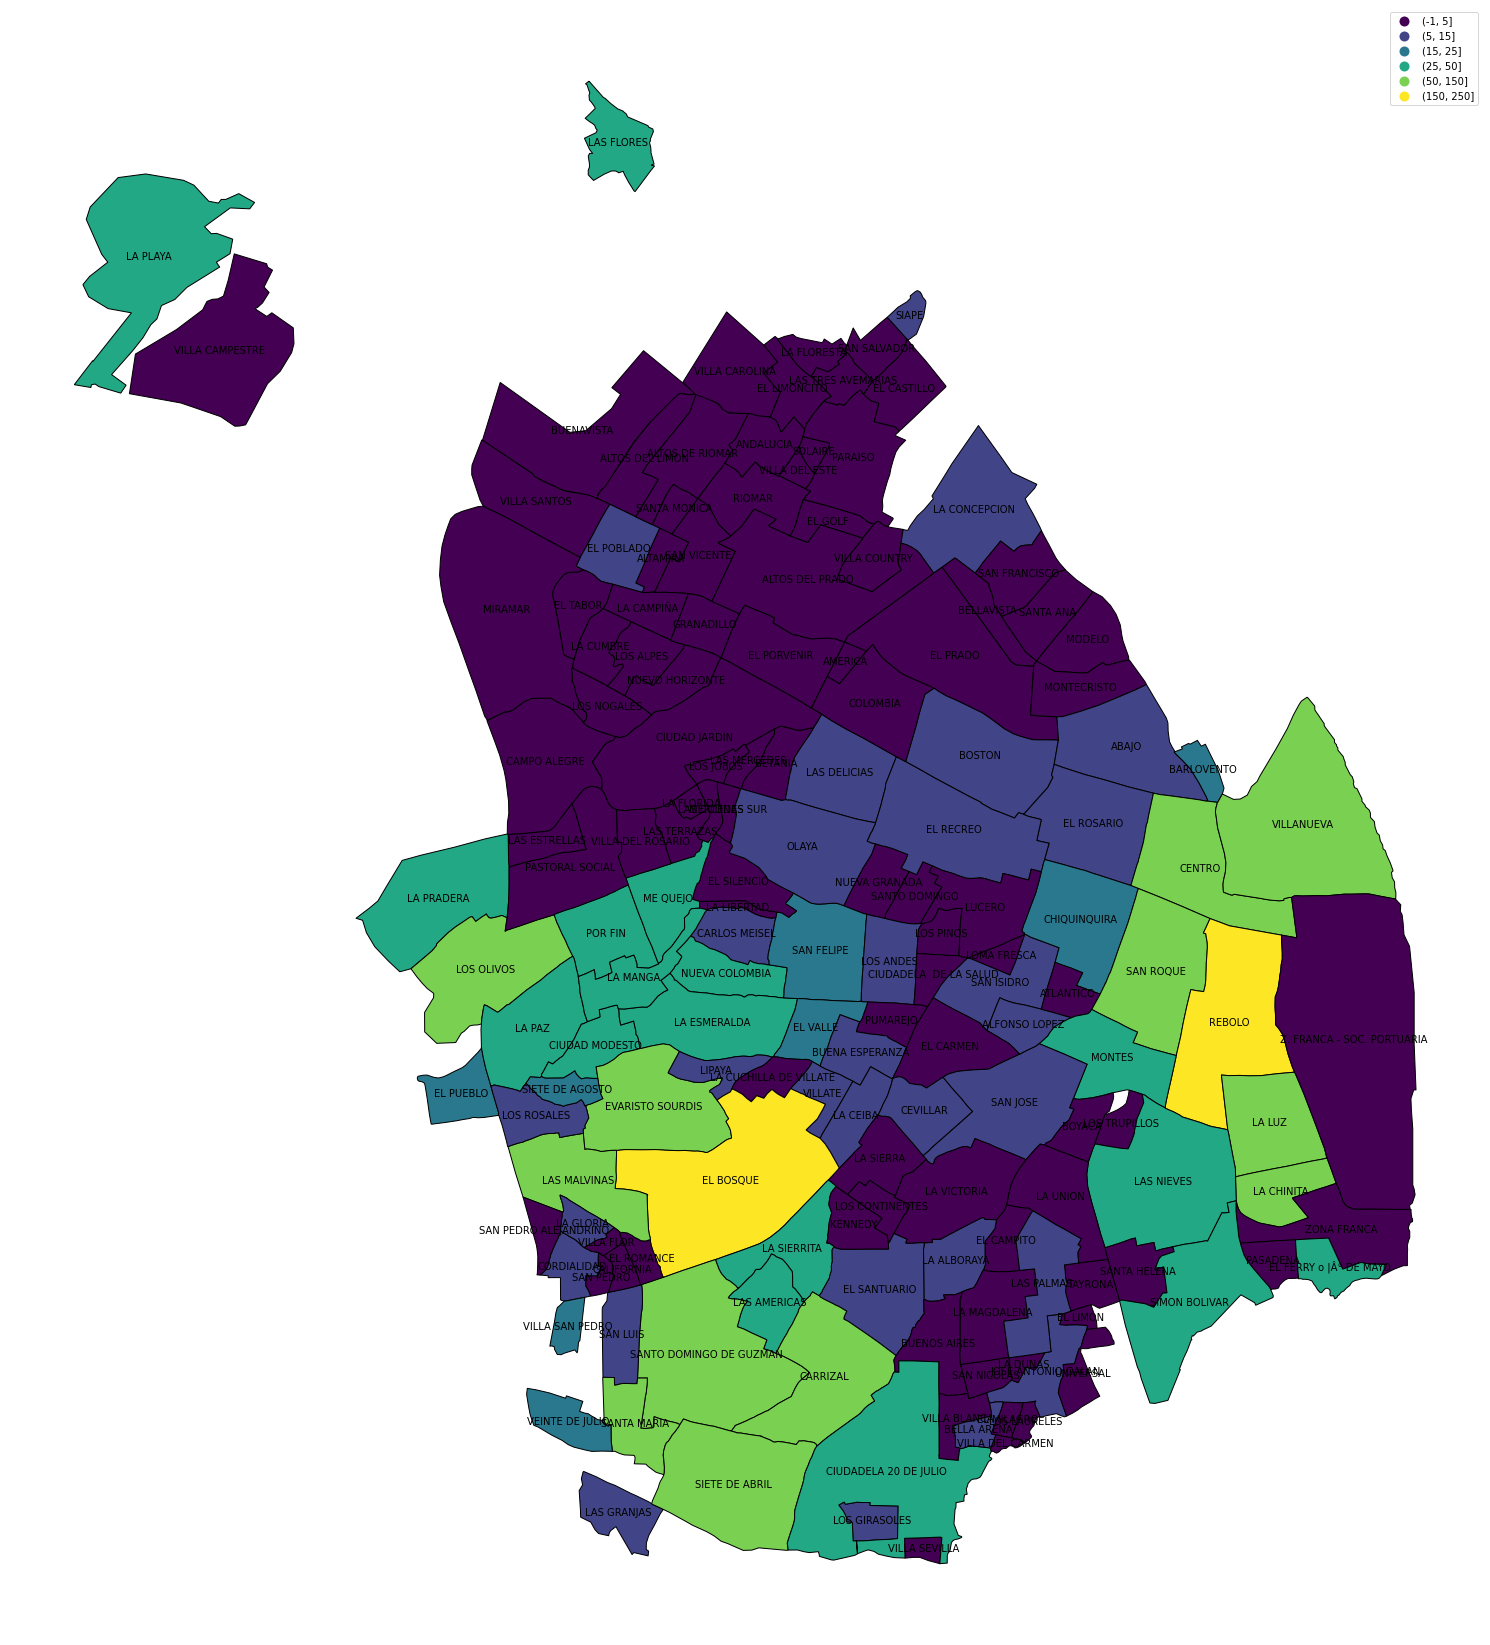

In [77]:
# Graficamos:
MAP.plot(column="rang_cant",figsize=(60,30) , legend=True, edgecolor='black',colormap="viridis")
# Los siguientes códigos permiten incluir los nombres de los barrios
for index,row in MAP.iterrows():
    xy=row['geometry'].centroid.coords[:]
    xytext=row['geometry'].centroid.coords[:]
    plt.annotate(row['NOMBRE_DE_'],xy=xy[0], xytext=xytext[0],  horizontalalignment='center',verticalalignment='center')
    plt.axis('off')
   

C:\Users\Keyla Alba\anaconda3\lib\site-packages\geopandas\plotting.py:642: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(


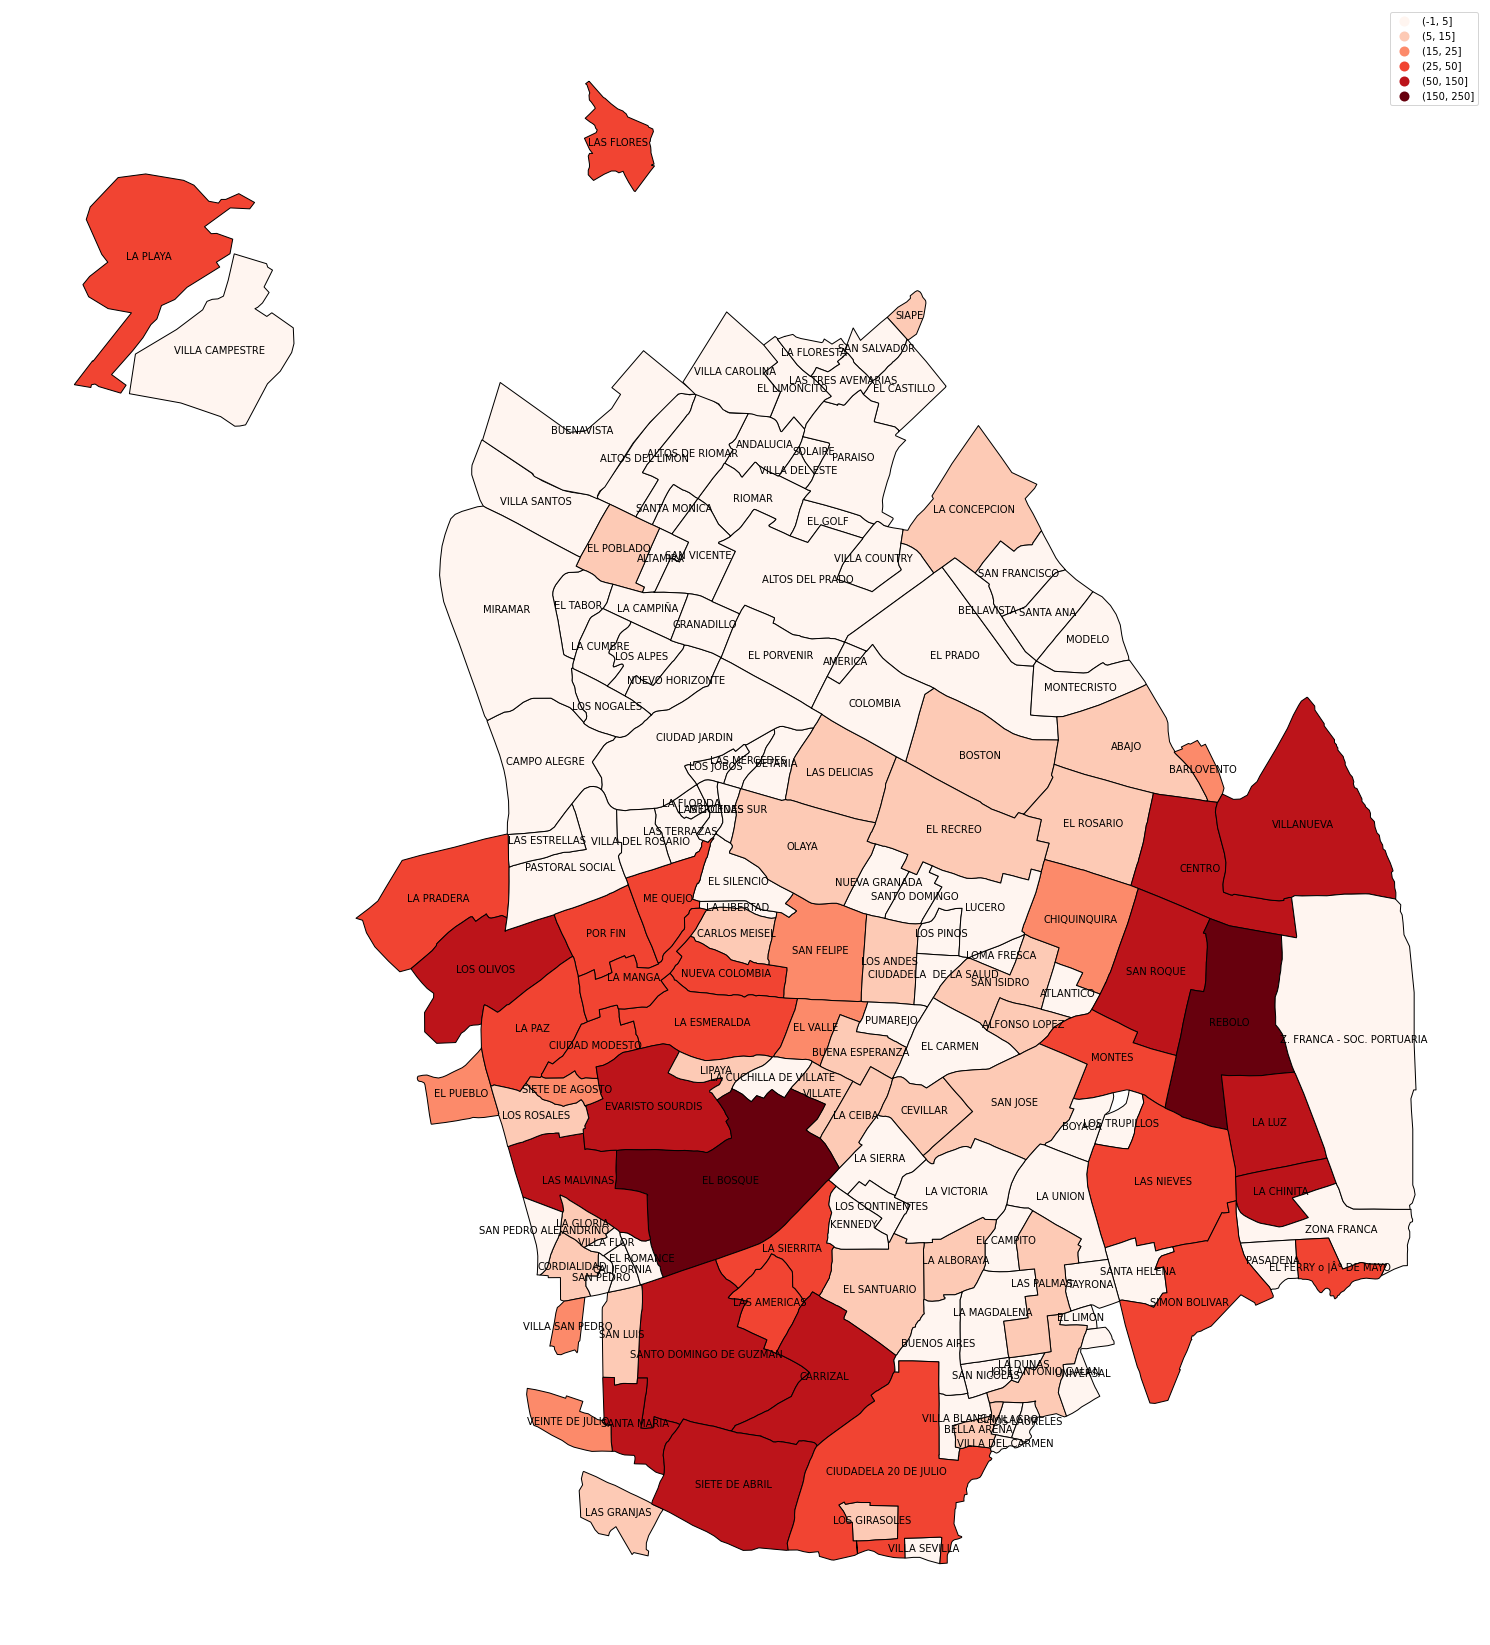

In [78]:
# Graficamos:
MAP.plot(column="rang_cant",figsize=(60,30) , legend=True, edgecolor='black',colormap="Reds")
# Los siguientes códigos permiten incluir los nombres de los municipios
for index,row in MAP.iterrows():
    xy=row['geometry'].centroid.coords[:]
    xytext=row['geometry'].centroid.coords[:]
    plt.annotate(row['NOMBRE_DE_'],xy=xy[0], xytext=xytext[0],  horizontalalignment='center',verticalalignment='center')
    plt.axis('off')

Mapa de calor del 2014-2017

In [79]:
BAQ.head(n=2)

,Fecha,Año,Delito,DELITO_COD,Mes,Departamento,Municipio,Día,g,Hora_D,BARRIO_COD,SITIO_COD,ARMA_COD,Edad,SEXO_COD,Nacionalidad,Cantidad
0,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,20:45:00,20,100,1,2,19,1,1,1
1,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,21:45:00,21,61,1,3,58,2,4,1


In [80]:
BAQ["Año"] = BAQ["Año"].astype('int')

In [82]:
filter1_baq = BAQ.loc[(BAQ['Año'] >= 2014)& (BAQ['Año'] <= 2017)]

In [83]:
filter1_baq.head(n=50)

,Fecha,Año,Delito,DELITO_COD,Mes,Departamento,Municipio,Día,g,Hora_D,BARRIO_COD,SITIO_COD,ARMA_COD,Edad,SEXO_COD,Nacionalidad,Cantidad
0,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,20:45:00,20,100,1,2,19,1,1,1
1,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,21:45:00,21,61,1,3,58,2,4,1
2,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,22:45:00,22,64,1,3,25,1,1,1
3,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,23:45:00,23,122,1,2,28,1,1,1
4,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,1900-01-01 00:45:00,0,122,1,2,32,1,1,1
5,2014-01-01,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,1900-01-01 01:45:00,1,108,1,2,20,1,1,1
6,2014-01-02,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Jueves,1900-01-01 02:45:00,2,44,1,4,28,1,1,1
7,2014-01-02,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Jueves,1900-01-01 03:45:00,3,43,1,2,28,2,1,1
8,2014-01-04,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,1900-01-01 04:45:00,4,68,1,2,19,1,1,1
9,2014-01-05,2014,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Domingo,1900-01-01 05:45:00,5,57,1,3,21,1,1,1


In [84]:
filter1_baq.shape

(1459, 17)

In [85]:
#para crear un resumen agrupando por las variables clase_acci y año, las tres variabbles numericas de los datos
resum_4 = filter1_baq.groupby(["BARRIO_COD"]).sum()[["Cantidad"]]
 
resum_4

,Cantidad
BARRIO_COD,
1,21
2,1
4,7
5,2
8,3
...,...
154,6
155,1
158,17


In [86]:
resum_4.reset_index(inplace=True) # para evitar que la variable sea leida como indice

resum_4

,BARRIO_COD,Cantidad
0,1,21
1,2,1
2,4,7
3,5,2
4,8,3
...,...,...
118,154,6
119,155,1
120,158,17
121,159,1


In [87]:
resum_4=resum_4[resum_4["BARRIO_COD"]<162]#Se excluye juan mina y otros barrios fuera de barranquilla
resum_4.tail(n=5)

,BARRIO_COD,Cantidad
118,154,6
119,155,1
120,158,17
121,159,1
122,161,1


In [88]:
# para cambiar el nombre DPTO_CNMBR por departamento y coincida con la anterior matriz de datos 
resum_4.rename(columns={"BARRIO_COD": "ID"},inplace=True)
resum_4.head()

,ID,Cantidad
0,1,21
1,2,1
2,4,7
3,5,2
4,8,3


In [90]:
MAP2=pd.merge(DATOS_mcol,resum_4, on = 'ID',how = 'outer')# para unir las dos matrices por departamento y quede en la matriz
#con georeferenias el precio promedio de la gasolina corriente 
MAP2.head(n=2)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry,Cantidad
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1...",21.0
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1...",1.0


In [91]:
MAP2['Cantidad'] = MAP2['Cantidad'].fillna(0)

In [92]:
MAP2.describe(include="all")

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry,Cantidad
count,161,159.000000,1.590000e+02,161.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,161,161.000000
unique,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161,NaN
top,LAS FLORES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POLYGON ((917842.5846864765 1713450.9322272616...,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
mean,NaN,920156.914239,1.705328e+06,81.000000,3.452830,110.742138,0.006289,1.899371,0.295597,2.635220,0.301887,4.534591,NaN,9.062112
std,NaN,2064.651863,3.023591e+03,46.620811,6.525217,130.520100,0.079305,2.250724,0.868240,3.294455,0.898344,5.076354,NaN,17.355003
min,NaN,913738.649000,1.699757e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,918543.105500,1.702729e+06,41.000000,0.000000,30.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,1.000000
50%,NaN,920069.614000,1.705122e+06,81.000000,1.000000,71.000000,0.000000,1.000000,0.000000,2.000000,0.000000,3.000000,NaN,3.000000
75%,NaN,921645.691000,1.707714e+06,121.000000,3.000000,152.000000,0.000000,3.000000,0.000000,4.000000,0.000000,6.500000,NaN,9.000000


In [93]:
MAP2["rang_cant"] = pd.cut(MAP2["Cantidad"],bins=[-1,5,15,25,50,150])


C:\Users\Keyla Alba\anaconda3\lib\site-packages\geopandas\plotting.py:642: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(
C:\Users\Keyla Alba\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 145 (\x91) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


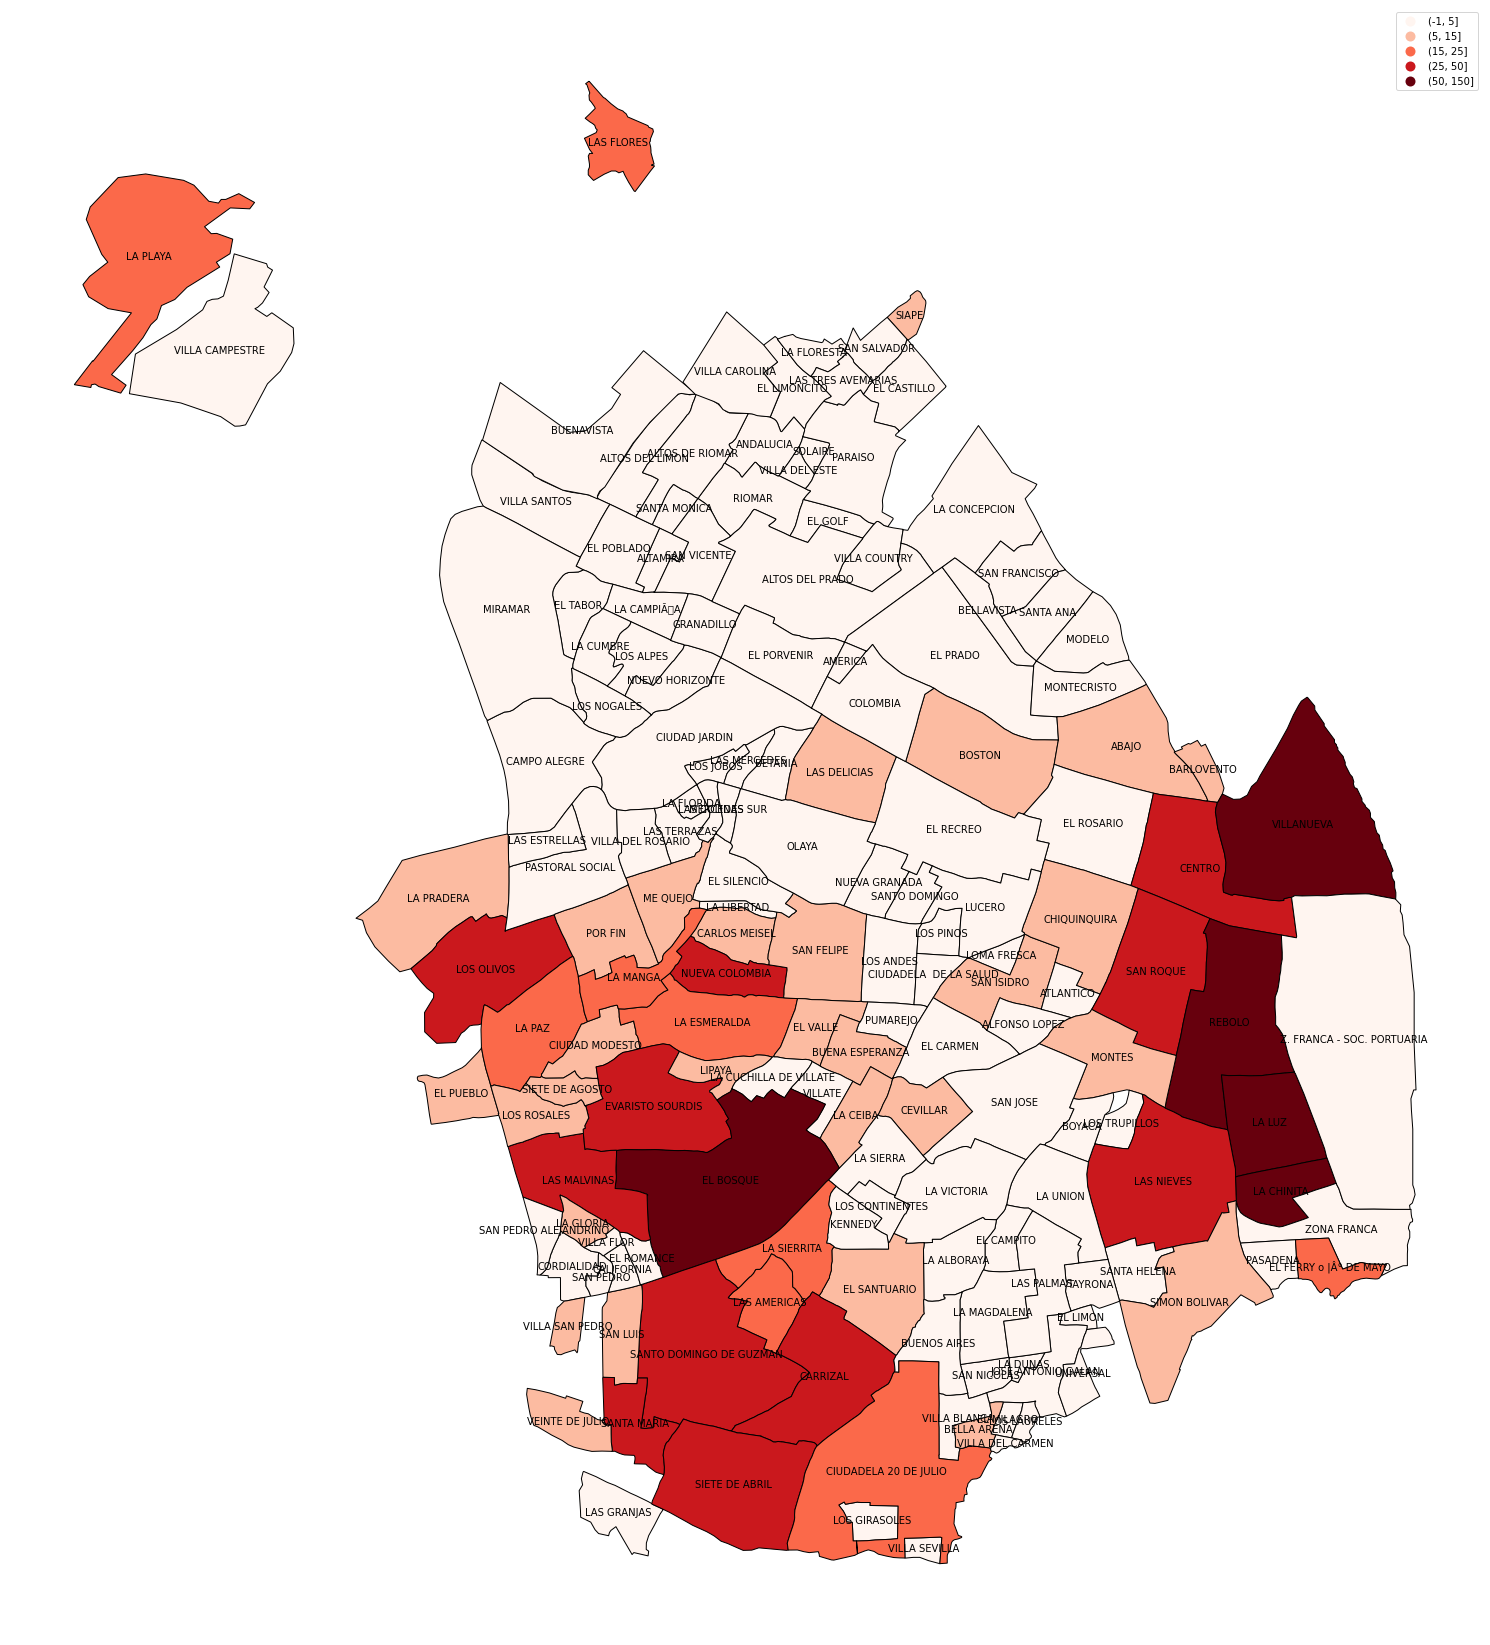

In [94]:
# Graficamos:
MAP2.plot(column="rang_cant",figsize=(60,30) , legend=True, edgecolor='black',colormap="Reds")
# Los siguientes códigos permiten incluir los nombres de los municipios
for index,row in MAP2.iterrows():
    xy=row['geometry'].centroid.coords[:]
    xytext=row['geometry'].centroid.coords[:]
    plt.annotate(row['NOMBRE_DE_'],xy=xy[0], xytext=xytext[0],  horizontalalignment='center',verticalalignment='center')
    plt.axis('off')

Mapa de calor del 2018-2021

In [95]:
filter2_baq = BAQ.loc[(BAQ['Año'] >= 2018)& (BAQ['Año'] <= 2021)]

In [96]:
filter2_baq.head(n=50)

,Fecha,Año,Delito,DELITO_COD,Mes,Departamento,Municipio,Día,g,Hora_D,BARRIO_COD,SITIO_COD,ARMA_COD,Edad,SEXO_COD,Nacionalidad,Cantidad
532,2018-01-27,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,06:38:00,6,88,7,6,24,1,1,1
544,2018-01-27,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,06:38:00,6,88,7,6,28,1,1,1
551,2018-01-27,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,06:38:00,6,88,7,6,29,1,1,2
558,2018-01-27,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,06:38:00,6,88,7,6,31,1,1,1
559,2018-01-27,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,06:38:00,6,88,7,6,32,1,1,1
1464,2018-01-03,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,15:50:00,15,99,1,2,21,1,1,1
1465,2018-01-06,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Sábado,13:40:00,13,98,1,2,38,1,1,1
1466,2018-01-10,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,15:00:00,15,67,1,3,16,1,1,1
1467,2018-01-10,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Miércoles,18:20:00,18,61,1,2,38,1,1,1
1468,2018-01-12,2018,Homicidio,5,1,ATLÁNTICO,BARRANQUILLA (CT),Viernes,21:00:00,21,101,1,2,29,1,1,1


In [97]:
filter2_baq.shape

(1183, 17)

In [98]:
#para crear un resumen agrupando por las variables clase_acci y año, las tres variabbles numericas de los datos
resum_5 = filter2_baq.groupby(["BARRIO_COD"]).sum()[["Cantidad"]]
 
resum_5

,Cantidad
BARRIO_COD,
1,23
2,1
4,3
5,3
11,3
...,...
155,4
158,20
159,1


In [99]:
resum_5.reset_index(inplace=True) # para evitar que la variable sea leida como indice

resum_5

,BARRIO_COD,Cantidad
0,1,23
1,2,1
2,4,3
3,5,3
4,11,3
...,...,...
112,155,4
113,158,20
114,159,1
115,161,1


In [100]:
resum_5=resum_5[resum_5["BARRIO_COD"]<162]#Se excluye juan mina y otros barrios fuera de barranquilla
resum_5.tail(n=5)

,BARRIO_COD,Cantidad
111,154,1
112,155,4
113,158,20
114,159,1
115,161,1


In [101]:
# para cambiar el nombre DPTO_CNMBR por departamento y coincida con la anterior matriz de datos 
resum_5.rename(columns={"BARRIO_COD": "ID"},inplace=True)
resum_5.head()

C:\Users\Keyla Alba\AppData\Local\Temp\ipykernel_9336\2052061781.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resum_5.rename(columns={"BARRIO_COD": "ID"},inplace=True)


,ID,Cantidad
0,1,23
1,2,1
2,4,3
3,5,3
4,11,3


In [102]:
MAP3=pd.merge(DATOS_mcol,resum_5, on = 'ID',how = 'outer')# para unir las dos matrices por departamento y quede en la matriz
#con georeferenias el precio promedio de la gasolina corriente 
MAP3.head(n=2)

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry,Cantidad
0,LAS FLORES,918113.667,1712875.681,1,11.0,71.0,0.0,0.0,0.0,2.0,0.0,2.0,"POLYGON ((917842.585 1713450.932, 917978.278 1...",23.0
1,EL LIMONCITO,919743.464,1710582.623,2,1.0,35.0,0.0,2.0,0.0,1.0,0.0,3.0,"POLYGON ((919914.066 1710698.308, 919975.534 1...",1.0


In [104]:
MAP3['Cantidad'] = MAP3['Cantidad'].fillna(0)

In [106]:
MAP3.describe(include="all")

,NOMBRE_DE_,X_Coord,Y_Coord,ID,HOM TOT,HP TOT,HOM CM,HP CM,HOM PM,HP PM,HOMICIDIOS,HURTOS MOT,geometry,Cantidad
count,161,159.000000,1.590000e+02,161.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,161,161.000000
unique,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,161,NaN
top,LAS FLORES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POLYGON ((917842.5846864765 1713450.9322272616...,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
mean,NaN,920156.914239,1.705328e+06,81.000000,3.452830,110.742138,0.006289,1.899371,0.295597,2.635220,0.301887,4.534591,NaN,7.347826
std,NaN,2064.651863,3.023591e+03,46.620811,6.525217,130.520100,0.079305,2.250724,0.868240,3.294455,0.898344,5.076354,NaN,13.675371
min,NaN,913738.649000,1.699757e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,918543.105500,1.702729e+06,41.000000,0.000000,30.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,0.000000
50%,NaN,920069.614000,1.705122e+06,81.000000,1.000000,71.000000,0.000000,1.000000,0.000000,2.000000,0.000000,3.000000,NaN,2.000000
75%,NaN,921645.691000,1.707714e+06,121.000000,3.000000,152.000000,0.000000,3.000000,0.000000,4.000000,0.000000,6.500000,NaN,7.000000


In [107]:
MAP3["rang_cant"] = pd.cut(MAP3["Cantidad"],bins=[-1,5,15,25,50,150])

C:\Users\Keyla Alba\anaconda3\lib\site-packages\geopandas\plotting.py:642: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(
C:\Users\Keyla Alba\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 145 (\x91) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


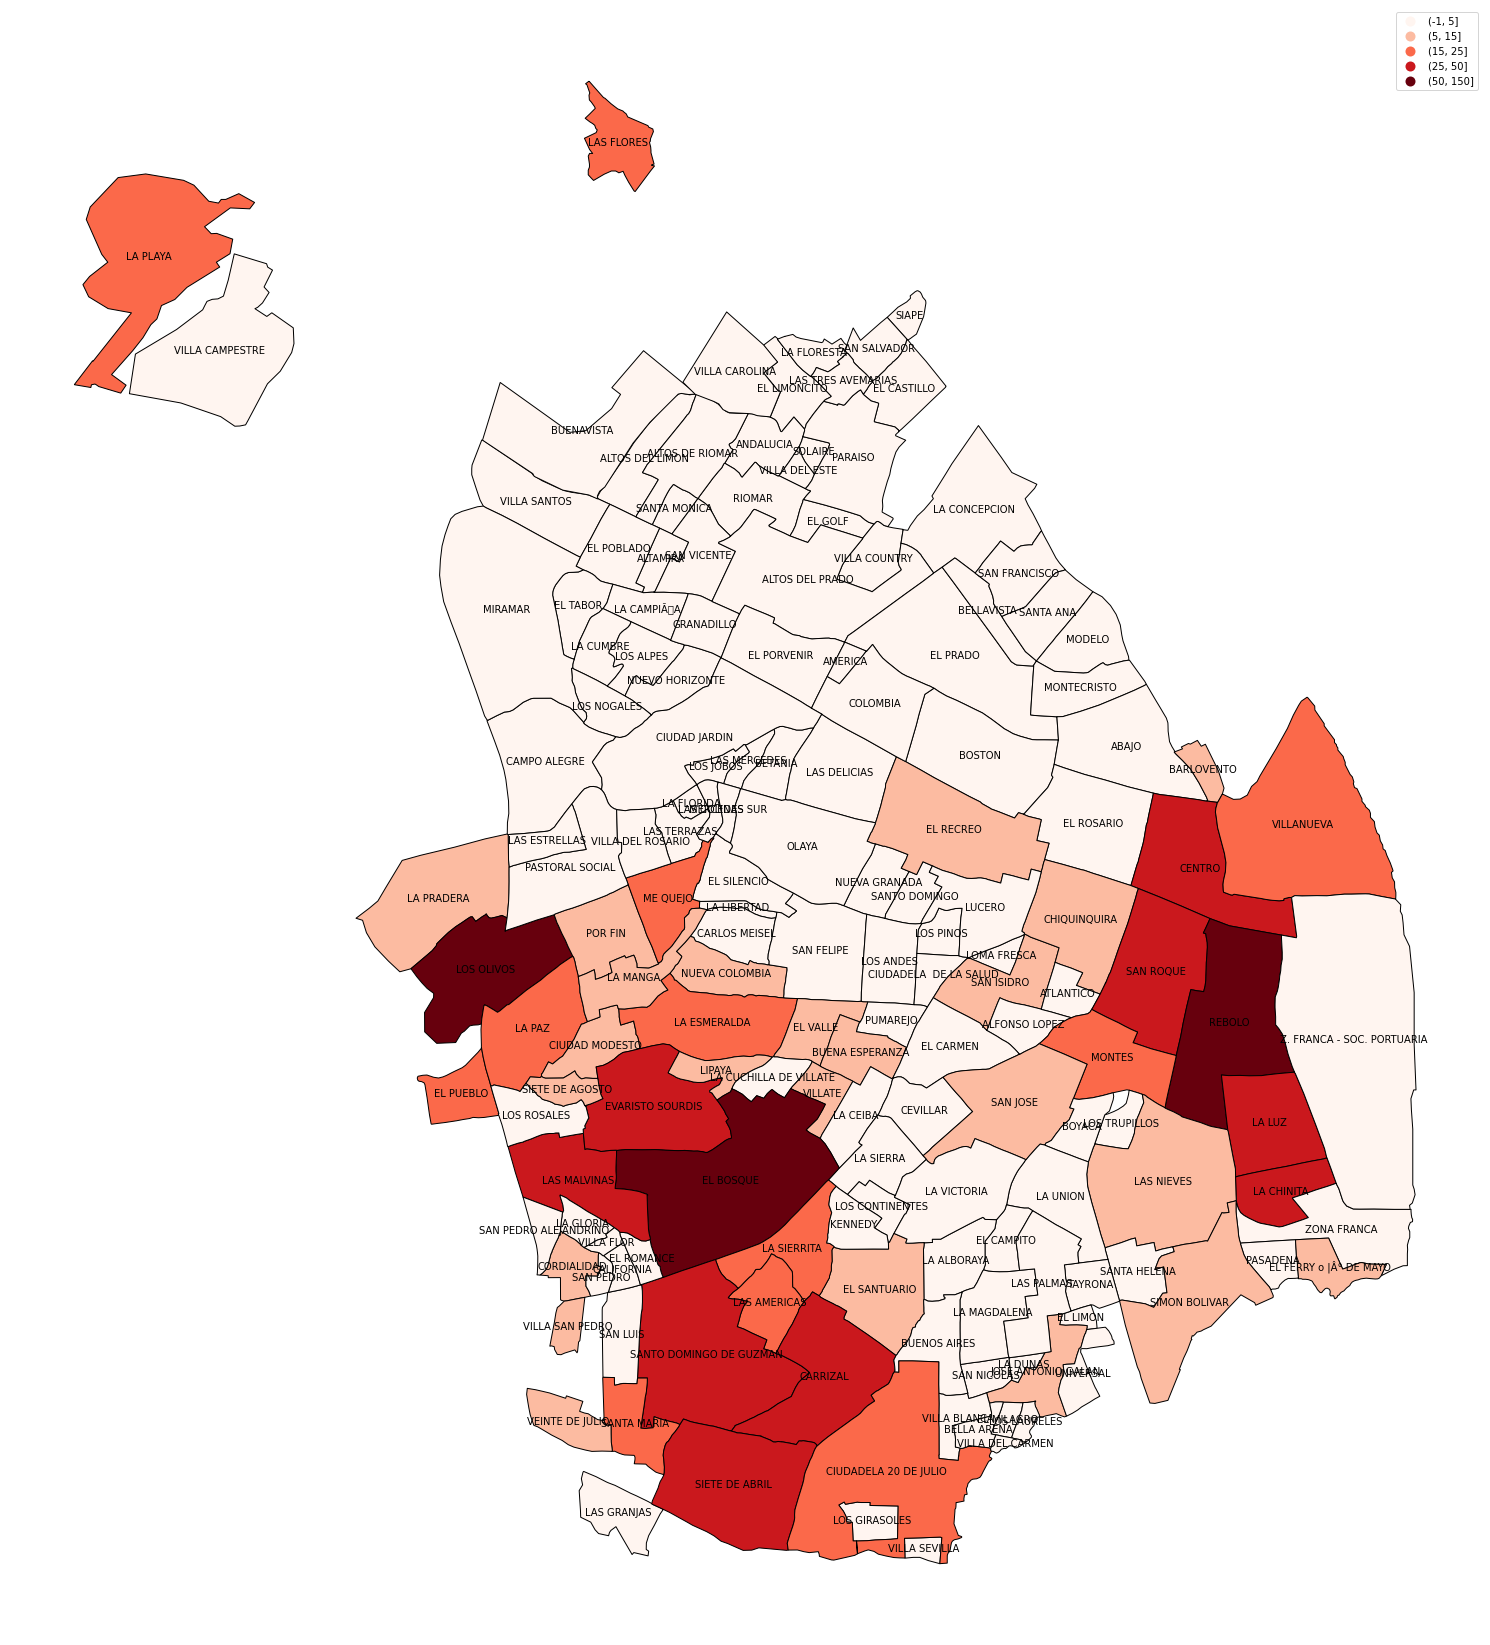

In [108]:
# Graficamos:
MAP3.plot(column="rang_cant",figsize=(60,30) , legend=True, edgecolor='black',colormap="Reds")
# Los siguientes códigos permiten incluir los nombres de los municipios
for index,row in MAP3.iterrows():
    xy=row['geometry'].centroid.coords[:]
    xytext=row['geometry'].centroid.coords[:]
    plt.annotate(row['NOMBRE_DE_'],xy=xy[0], xytext=xytext[0],  horizontalalignment='center',verticalalignment='center')
    plt.axis('off')